***[May 21]***

Idea: Each restaurant is an independent series and has separate covariate series


In [1]:
%cd ../../

/Users/hoangle/Projects/untangling-people/ylva/fwo_models


In [2]:
import datetime

import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import numpy as np
from darts.timeseries import concatenate
from darts import TimeSeries
from sklearn.metrics import mean_absolute_percentage_error
from darts.models import CatBoostModel, TFTModel, TransformerModel, TSMixerModel, RNNModel, XGBModel, LightGBMModel, NBEATSModel, LinearRegressionModel, RandomForest
from darts.dataprocessing.transformers import Scaler
from sklearn.preprocessing import MinMaxScaler

In [3]:
plt.style.use('seaborn-v0_8')
plt.rcParams.update({'font.size': 8})

# Load data and dims

## Load and process data

In [4]:
EPS = 1e-6

In [5]:
path =  "data/processed/pos_daily_snapshot.parquet"
pos_daily_snapshot = pl.read_parquet(path)

pos_daily_snapshot.head()

id,restaurant,date,pcs,src
u32,i64,date,i64,list[str]
0,3,2024-05-30,79,"[""Sold lunches""]"
1,3,2024-09-24,260,"[""Sold lunches Kumpula 9-10 2024""]"
2,3,2025-03-21,120,"[""Physicum lounaat ja hiilijalanjäljet 01112024-31032025""]"
3,1,2024-12-19,661,"[""Chemicum lounaat ja hiilijalanjäljet 01112024-31032025""]"
4,1,2024-09-18,959,"[""Sold lunches Kumpula 9-10 2024""]"


In [6]:
path = "data/processed/dim_restaurants.xlsx"
dim_restaurants = pl.read_excel(path)

dim_restaurants.head()

restaurant_id,restaurant,restaurant_short
i64,str,str
1,"""600 Chemicum""","""che"""
2,"""620 Exactum""","""exa"""
3,"""610 Physicum""","""phy"""
4,"""570 Viikuna""","""vik"""


In [7]:
pos_daily_snapshot = (
    pos_daily_snapshot

    # Translate to restaurant name from restaurant id
    .join(dim_restaurants, left_on='restaurant', right_on='restaurant_id')
    .drop('restaurant_right', 'restaurant')
    .rename({'restaurant_short': 'restaurant'})


    # Pivot
    .pivot(index='date', on='restaurant', values='pcs')
    .sort('date')
)

pos_daily_snapshot.head()

date,phy,che,exa,vik
date,i64,i64,i64,i64
2023-01-02,null,348,null,null
2023-01-03,null,394,null,null
2023-01-04,null,428,null,null
2023-01-05,null,501,null,null
2023-01-09,33,578,99,280


In [8]:
# static_covs_multi = pd.DataFrame(data={"restaurant": [0, 1, 2, 3]})
# series = series.with_static_covariates(static_covs_multi)
# series.static_covariates

## Load dims

<Axes: xlabel='date'>

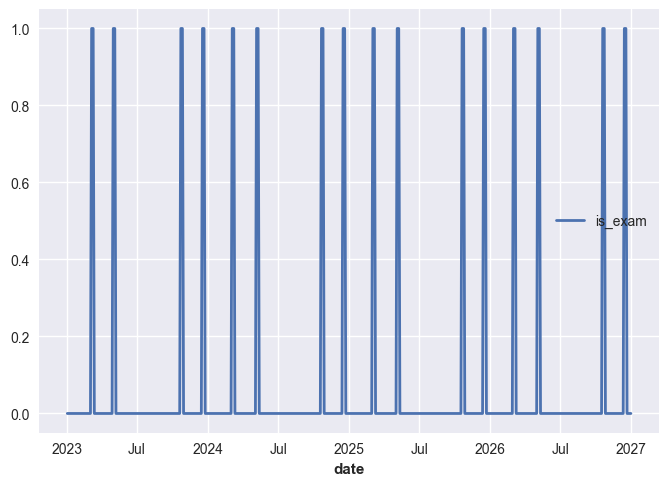

In [9]:
path = "data/processed/dim_exams_uhelsinki.xlsx"
dim_exam = (
     pl.read_excel(path)
    .filter(pl.col('date').dt.weekday() <= 5)
)


series_exam = (
    TimeSeries
    .from_dataframe(
        df=dim_exam.to_pandas(),
        time_col='date',
        freq='b',
        fill_missing_dates = False,
        value_cols='is_exam'
    )
)
series_exam.plot()

<Axes: xlabel='date'>

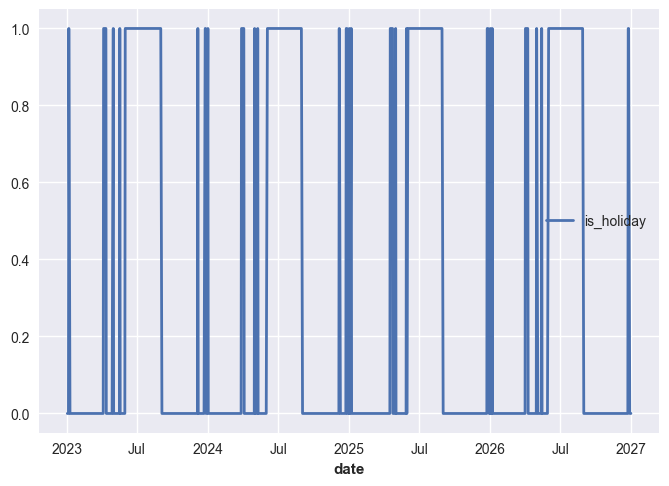

In [10]:
path = "data/processed/dim_holidays_uhelsinki.xlsx"
dim_holiday = (
    pl.read_excel(path)
    .filter(pl.col('date').dt.weekday() <= 5)
)


series_holiday = (
    TimeSeries
    .from_dataframe(
        df=dim_holiday.to_pandas(),
        time_col='date',
        freq='b',
        fill_missing_dates = True,
        value_cols='is_holiday'
    )
    # .astype(np.float32)
)
series_holiday.plot()


### Create series for target/covariate

In [15]:
CUTOFF_DATE = pd.to_datetime("2025-01-01")
restaurants = [
    'che',
    'exa',
    'phy',
    'vik'
]

# For covariate
series_cov = concatenate(
    [
        series_exam,
        series_holiday,
    ],
    axis=1
).astype(np.float32)

# For target and train/test
series_dict = {}

for restaurant in restaurants:
    tgt = TimeSeries.from_dataframe(
        pos_daily_snapshot.to_pandas(),
        time_col='date',
        value_cols=[restaurant],
        fillna_value=EPS,
        freq='B',
    )
    series_train, series_test = tgt.astype(np.float32).split_before(CUTOFF_DATE)

    # Transform
    transformer_target = Scaler(MinMaxScaler(feature_range=(-1, 1)))
    series_train_transformed = transformer_target.fit_transform(series_train)


    series_dict[restaurant] = {
        'tgt': tgt,
        'train': series_train_transformed,
        'test': series_test,
        'cov': series_cov,
        'tgt_scaler': transformer_target,
    }

# Train

<Axes: xlabel='date'>

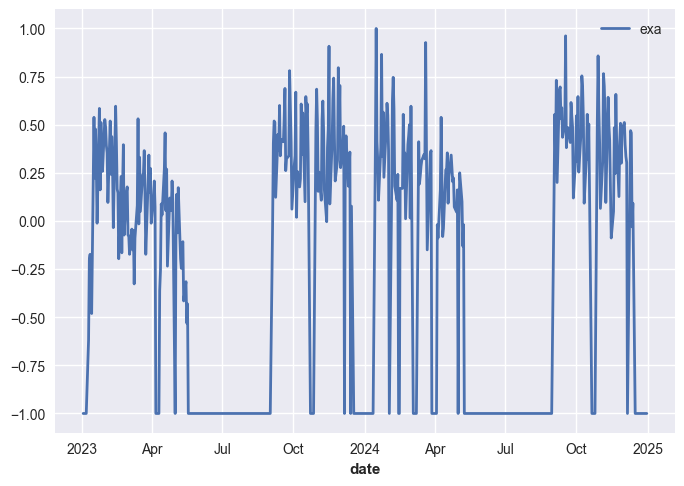

In [16]:
series_dict['exa']['train'].plot()

## ML and statistical models

In [17]:
model_name = "rnn"

input_chunk_length = 10
output_chunk_length = 10
num_epochs = 400


# Define params
add_encoders = {
    "datetime_attribute": {
        "future": ["dayofweek", 'day', 'month'],
        "past": ["dayofweek", 'day', 'month']
    },
    'cyclic': {
        'past': ["dayofweek", 'day', 'month'],
        'future': ["dayofweek", 'day', 'month']
    },
}

params_ml = {
    "lags": input_chunk_length,
    "lags_future_covariates": [0],
    "output_chunk_length": output_chunk_length,
    "add_encoders": {**add_encoders}
}
params_dl = {
    "input_chunk_length": input_chunk_length,
    "output_chunk_length": output_chunk_length,
    "add_encoders": {**add_encoders},  
    "n_epochs": num_epochs,
    "pl_trainer_kwargs": {'precision': "32-true",},
    "optimizer_kwargs": {
        'lr': 5e-4
    }
}

tgt = [restaurant['train'] for restaurant in series_dict.values()]
cov_future = [restaurant['cov'] for restaurant in series_dict.values()]
cov_past = [restaurant['cov'].split_before(CUTOFF_DATE)[0] for restaurant in series_dict.values()]
# model = TransformerModel(**params_dl)
# model.fit(series=tgt, past_covariates=cov)

# Define models
match model_name:
    # =================================================
    # ML models
    # =================================================
    case "linear":
        model = LinearRegressionModel(**params_ml)
        model.fit(series=tgt, future_covariates=cov_future)
    case "rf":
        model = RandomForest(**params_ml)
        model.fit(series=tgt, future_covariates=cov_future)
    case "catboost":
        model = CatBoostModel(**params_ml)
        model.fit(series=tgt, future_covariates=cov_future)
    case "xgboost":
        model = XGBModel(**params_ml)
        model.fit(series=tgt, future_covariates=cov_future)
    case "lightbgm":
        model = LightGBMModel(**params_ml)
        model.fit(series=tgt, future_covariates=cov_future)

    # =================================================
    # DL models
    # =================================================
    case "rnn":
        params_dl["model"] = "LSTM"

        model = RNNModel(**params_dl)
        model.fit(series=tgt, future_covariates=cov_future)
    case "tsmixer":
        model = TSMixerModel(**params_dl)
        model.fit(series=tgt, future_covariates=cov_future)
    case "transformer":
        model = TransformerModel(**params_dl)
        model.fit(series=tgt, past_covariates=cov_past)
    case "tft":
        params_dl["categorical_embedding_sizes"] = {"holiday": (2, 2), "exam": (2, 2), "restaurant": (4, 4)}

        model = TFTModel(**params_dl)
        model.fit(series=tgt, future_covariates=cov_future)
    case "n-beats":
        model = NBEATSModel(**params_dl)
        model.fit(series=tgt, past_covariates=cov_past)

    case _:
        raise NotImplementedError()

ignoring user defined `output_chunk_length`. RNNModel uses a fixed `output_chunk_length=1`.
Specified past encoders in `add_encoders` at model creation but model does not accept past covariates. past encoders will be ignored.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 3.9 K  | train
6 | V               | Linear           | 26     | train
-------------------------------------------------------------
3.9 K     Trainable params
0         Non-trainable params
3.9 K     Total params
0.016

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/hoangle/Projects/untangling-people/ylva/fwo_models/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Predicting: |          | 0/? [00:00<?, ?it/s]

mape_val: 0.2570


Text(0.5, 1.0, 'vik | mape = 25.7%')

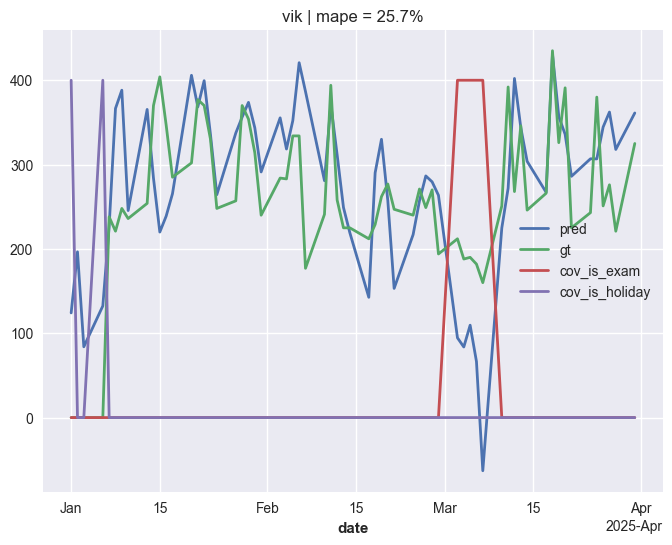

In [21]:
restaurant_name = 'vik'


restaurant = series_dict[restaurant_name]
forecast_horizon = len(series_dict[restaurant_name]['test'])

tgt = restaurant['train'][-input_chunk_length:]
cov_future = restaurant['cov']
cov_past = restaurant['cov'].split_before(CUTOFF_DATE)[0][-input_chunk_length:]

# prediction = model.predict(n=forecast_horizon, series=restaurant['train'], past_covariates=restaurant['cov'])



match model_name:
    # =================================================
    # ML models
    # =================================================
    case "linear":
        prediction = model.predict(n=forecast_horizon, series=tgt, future_covariates=cov_future)
    case "rf":
        prediction = model.predict(n=forecast_horizon, series=tgt, future_covariates=cov_future)
    case "catboost":
        prediction = model.predict(n=forecast_horizon, series=tgt, future_covariates=cov_future)
    case "xgboost":
        prediction = model.predict(n=forecast_horizon, series=tgt, future_covariates=cov_future)
    case "lightbgm":
        prediction = model.predict(n=forecast_horizon, series=tgt, future_covariates=cov_future)

    # =================================================
    # DL models
    # =================================================
    case "rnn":
        params_dl["model"] = "LSTM"

        prediction = model.predict(n=forecast_horizon, series=tgt, future_covariates=cov_future)
    case "tsmixer":
        prediction = model.predict(n=forecast_horizon, series=tgt, future_covariates=cov_future)
    case "transformer":
        prediction = model.predict(n=forecast_horizon, series=tgt, past_covariates=cov_past)
    case "tft":
        prediction = model.predict(n=forecast_horizon, series=tgt, future_covariates=cov_future)
    case "n-beats":
        prediction = model.predict(n=forecast_horizon, series=tgt, past_covariates=cov_past)

    case _:
        raise NotImplementedError()


# Transform prediction
series_pred = restaurant['tgt_scaler'].inverse_transform(prediction)
series_test = restaurant['test']

df = pd.concat(
    [
        series_test.to_dataframe().rename(columns={restaurant_name: "gt"}),
        series_pred.to_dataframe().rename(columns={restaurant_name: "pred"})
    ],
    axis=1
)
df = df[df['gt'] > EPS]

mape_val = mean_absolute_percentage_error(df['gt'], df['pred'])
print(f"mape_val: {mape_val:.4f}")

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
series_pred.plot(ax=ax, label='pred')
series_test.plot(ax=ax, label='gt')

dt_start, dt_end = series_test.time_index[0], series_test.time_index[-1]
(cov_future[dt_start: dt_end] * 400).plot(ax=ax, label='cov')

ax.set_title(f"{restaurant_name} | mape = {mape_val*100:.4}%")